In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.append(str(root / "src"))

In [3]:
import torch
import matplotlib.pyplot as plt

In [4]:
d = 8
pos = 5

i = torch.arange(d // 2)           # pair index: 0, 1, 2, 3
freq = 1.0 / 10000 ** (2 * i / d)  # one frequency per pair
angle = pos * freq                 # [d/2]

pe = torch.zeros(d)
pe[0::2] = torch.sin(angle)
pe[1::2] = torch.cos(angle)
pe


tensor([-0.9589,  0.2837,  0.4794,  0.8776,  0.0500,  0.9988,  0.0050,  1.0000])

In [5]:
freq, 2 * torch.pi / freq  # frequency, and wavelength (positions per full cycle)


(tensor([1.0000, 0.1000, 0.0100, 0.0010]),
 tensor([   6.2832,   62.8319,  628.3185, 6283.1851]))

In [6]:
for n in range(8):
    print(f"{n:04b}")


0000
0001
0010
0011
0100
0101
0110
0111


In [7]:
d = 64
max_len = 128

pos = torch.arange(max_len).unsqueeze(1)  # [T, 1]
i = torch.arange(d // 2)
freq = 1.0 / 10000 ** (2 * i / d)         # [d/2]
angle = pos * freq                        # [T, 1] * [d/2] -> [T, d/2]

pe = torch.zeros(max_len, d)
pe[:, 0::2] = torch.sin(angle)
pe[:, 1::2] = torch.cos(angle)
pe.shape


torch.Size([128, 64])

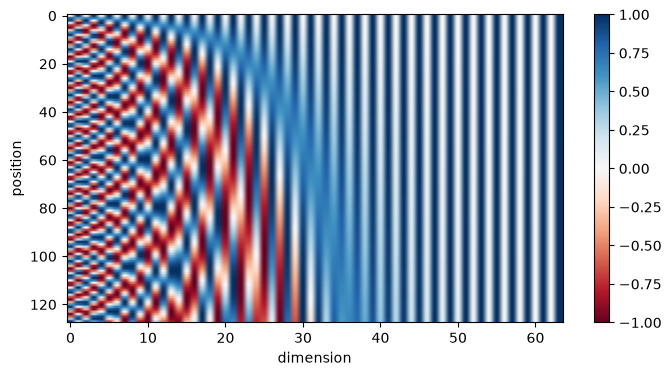

In [8]:
plt.figure(figsize=(8, 4))
plt.imshow(pe, aspect="auto", cmap="RdBu")
plt.xlabel("dimension")
plt.ylabel("position")
plt.colorbar()


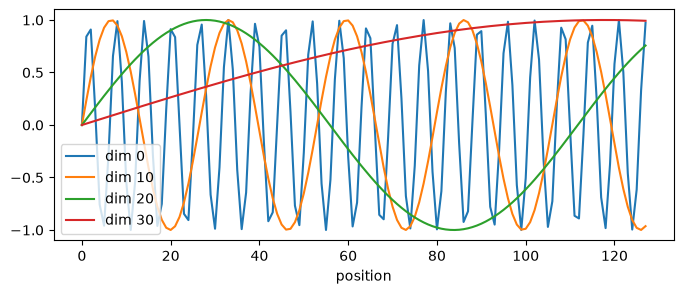

In [9]:
plt.figure(figsize=(8, 3))
for dim in [0, 10, 20, 30]:
    plt.plot(pe[:, dim], label=f"dim {dim}")
plt.xlabel("position")
plt.legend()
